# Figure 2 OncoKB event landscape

This notebook generates the event landscape used for Figure 2, combining:
- Sequenza-derived ploidy-adjusted copy-number events
- OncoKB-annotated somatic SNVs/indels
- HGVSp_Short annotations

This notebook also exports patient-specific event summary snippets used in the later manual assembly of phylogenetic summaries for Figure 4 and Figure S4.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import ast
import re
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib as mpl  
from collections import OrderedDict

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 120) 

In [ ]:
new_sample_list = \
['RAP-001_65852_T',
 'RAP-001_65847_T',
 'RAP-002_14015_T',
 'RAP-002_14071_T',
 'RAP-002_14009_T',
 'RAP-002_14057_T',
 'RAP-002_14029_T',
 'RAP-003_69675_T',
 'RAP-003_69443_T',
 'RAP-003_69692_T',
 'RAP-004_70735_T',
 'RAP-004_70676_T',
 'RAP-004_70385_T',
 'RAP-004_70939_T',
 'RAP-004_70396_T',
 'RAP-004_70647_T',
 'RAP-004_70370_T',
 'RAP-004_70401_T',
 'RAP-005_179178_T',
 'RAP-005_179317_T',
 'RAP-005_179141_T',
 'RAP-005_179174_T',
 'RAP-005_179337_T',
 'RAP-005_179131_T',
 'RAP-005_179341_T',
 'RAP-006_150206_T',
 'RAP-006_150169_T',
 'RAP-006_150153_T',
 'RAP-006_150124_T',
 'RAP-006_150264_T',
 'RAP-006_150175_T',
 'RAP-006_150200_T',
 'RAP-006_150289_T',
 'RAP-006_150274_T',
 'RAP-006_150230_T',
 'RAP-006_150113_T',
 'RAP-006_150139_T',
 'RAP-006_150145_T',
 'RAP-007_245081_T',
 'RAP-007_245138_T',
 'RAP-007_244988_T',
 'RAP-007_244103_T',
 'RAP-007_245184_T',
 'RAP-007_244126_T',
 'RAP-007_245062_T',
 'RAP-007_244120_T',
 'RAP-007_245163_T',
 'RAP-007_245725_T']

In [ ]:
working_dir = 'PATH_TO_SEQUENZA_RESULTS'

os.chdir(working_dir)

temp_files = sorted([i for i in os.listdir(working_dir) if ('DS' not in i) and ('chromosome_views' not in i) \
                    and ('sequenza_segments' not in i)])

confints_cp_dfs = {}

for sample_name in temp_files:
    
    sample_dir = working_dir + sample_name + '/' + sample_name + '_confints_CP.txt'
    confints_cp_dfs[sample_name] = pd.read_csv(sample_dir, sep='\t', low_memory=False) 
    
cellularity_dict = {}
ploidy_dict = {}

for sample_name in new_sample_list:
    
    if len(confints_cp_dfs[sample_name]) != 3:
        
        print(sample_name)
        
    cellularity_dict[sample_name] = confints_cp_dfs[sample_name].iloc[1]['cellularity']
    ploidy_dict[sample_name] = confints_cp_dfs[sample_name].iloc[1]['ploidy.estimate']

In [53]:
immune_response_genes = {
    'DNA_damage_repair': ['MSH2', 'MSH6', 'MLH1', 'PMS2', 'POLE', 'BRCA2'],
    'MAPK_pathway': ['KRAS', 'NRAS', 'STK11', 'TP53', 'KIT'],
    'PI3K_AKT_mTOR_pathway': ['PTEN', 'PIK3CA', 'AKT1', 'AKT2', 'AKT3', 'EGFR'],
    'WNT_b_catenin_pathway': ['DKK2', 'BRAF', 'CTNNB1'],
    'IDO_pathway': ['IDO1'],
    'TGFbeta': ['TGFB1'],
    'HLA_pathways': ['B2M', 'HLA-A', 'HLA-B', 'HLA-C', 'TAP1', 'TAP2'],
    'JAK_STAT_pathway': ['IFNGR1', 'JAK1', 'JAK2', 'JAK3', 'APLNR', 'SOCS1'],
    'IFNg_signaling': ['STAT1', 'IFNGR2', 'IRF1', 'PTPN2'],
    'immune_checkpoint': ['PDCD1', 'CD274'],
    'chromatin_remodeling': ['ARID1A', 'PBRM1', 'SMARCA4', 'EZH2'],
    'hippo_signaling': ['YAP1', 'MYCN', 'MYC'],
    'anti_CTLA4': ['SERPINB3', 'SERPINB4']
}

In [54]:
all_immune_response_genes = [gene for pathway in immune_response_genes for gene in immune_response_genes[pathway]]

# OncoKB

In [ ]:
oncokb_dir = 'PATH_TO_ONCOKB_TABLES'

os.chdir(oncokb_dir)

temp_files = sorted([i for i in os.listdir(oncokb_dir) if i[:-4] in new_sample_list])

In [7]:
oncokb_annotated_dfs = {}

for file in temp_files:
    
    oncokb_annotated_dfs[file[:-4]] = pd.read_csv(oncokb_dir + file, sep='\t', low_memory=False)

In [ ]:
cosmic_dir = 'PATH_TO_COSMIC_CENSUS_TSV'

cosmic_df = pd.read_csv(cosmic_dir, sep='\t', low_memory=False)

In [ ]:
cosmic_gene_list = cosmic_df['Gene Symbol'].tolist()

oncogenic_level_of_interest = ['Oncogenic', 'Likely Oncogenic', 'Resistance']

included_var_class = \
['Frame_Shift_Del',
 'Frame_Shift_Ins',
 'In_Frame_Del',
 'In_Frame_Ins',
 'Missense_Mutation',
 'Nonsense_Mutation',
 'Splice_Site',
 'Translation_Start_Site']

In [14]:
oncokb_oncogenic_dfs = {}

for df_name in oncokb_annotated_dfs:
    
    temp_df = oncokb_annotated_dfs[df_name]
    
    temp_var_of_interest_df = temp_df[temp_df['Variant_Classification'].isin(included_var_class)]
    
    oncokb_oncogenic_dfs[df_name] = \
    temp_var_of_interest_df[temp_var_of_interest_df['ONCOGENIC'].isin(oncogenic_level_of_interest)]

In [15]:
oncokb_cosmic_dfs = {}

for df_name in oncokb_annotated_dfs:
    
    temp_df = oncokb_annotated_dfs[df_name]
    
    temp_var_of_interest_df = temp_df[temp_df['Variant_Classification'].isin(included_var_class)]
    
    temp_non_oncogenic_df = \
    temp_var_of_interest_df[~temp_var_of_interest_df['ONCOGENIC'].isin(oncogenic_level_of_interest)]
    
    oncokb_cosmic_dfs[df_name] = \
    temp_non_oncogenic_df[temp_non_oncogenic_df['Hugo_Symbol'].isin(cosmic_gene_list)]

# Sequenza

In [ ]:
working_dir = 'PATH_TO_SEQUENZA_RESULTS'

os.chdir(working_dir)

temp_files = sorted([i for i in os.listdir(working_dir) if ('DS' not in i) and ('chromosome_views' not in i) \
                    and ('sequenza_segments' not in i)])

In [19]:
segment_dfs = {}

for sample_name in temp_files:
    
    if sample_name in new_sample_list:
        
        sample_dir = working_dir + sample_name + '/' + sample_name + '_segments.txt'
        segment_dfs[sample_name] = pd.read_csv(sample_dir, sep='\t', low_memory=False) 

In [20]:
oncokb_oncogenic_dfs_sequenza = {}

for df_name in oncokb_oncogenic_dfs:
    
    temp_output_df = oncokb_oncogenic_dfs[df_name].copy()
    temp_sequenza_df = segment_dfs[df_name]

    new_column_overlap_flag = []
    new_column_overlap_interval = []
    new_column_overlap_CNt = []

    for index, row in temp_output_df.iterrows():
        
        temp_chrom_df = temp_sequenza_df[temp_sequenza_df['chromosome'] == row['Chromosome']]

        temp_overlap_df = temp_chrom_df[
            (temp_chrom_df['start.pos'] <= row['End_Position']) &
            (temp_chrom_df['end.pos'] >= row['Start_Position'])
        ]
        
        temp_init_overlap_abnormal_df = temp_overlap_df[abs(temp_overlap_df['CNt'] - ploidy_dict[df_name]) >= 0.5]
        
        if (ploidy_dict[df_name] == 1.5) or ploidy_dict[df_name] == 2.5:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df[temp_init_overlap_abnormal_df['CNt'] != 2]
                    
        else:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df
        
        if not temp_overlap_abnormal_df.empty:
            
            if len(temp_overlap_abnormal_df) == 1:
                
                new_column_overlap_flag.append(1)
                new_column_overlap_interval.append([
                    (temp_overlap_abnormal_df.iloc[0]['start.pos'], temp_overlap_abnormal_df.iloc[0]['end.pos'])
                ])
                new_column_overlap_CNt.append([temp_overlap_abnormal_df.iloc[0]['CNt']])
                
            else:
                
                temp_output_flags = []
                temp_output_intervals = []
                temp_output_CNts = []

                for i, r in temp_overlap_abnormal_df.iterrows():
                    
                    temp_output_flags.append(1)
                    temp_output_intervals.append((r['start.pos'], r['end.pos']))
                    temp_output_CNts.append(r['CNt'])

                new_column_overlap_flag.append(temp_output_flags)
                new_column_overlap_interval.append(temp_output_intervals)
                new_column_overlap_CNt.append(temp_output_CNts)
        
        else:
            
            new_column_overlap_flag.append(0)
            new_column_overlap_interval.append([])
            new_column_overlap_CNt.append([])

    temp_output_df['overlap_flag'] = new_column_overlap_flag
    temp_output_df['overlap_intervals'] = new_column_overlap_interval
    temp_output_df['overlap_CNt'] = new_column_overlap_CNt

    oncokb_oncogenic_dfs_sequenza[df_name] = temp_output_df.copy()


In [24]:
oncokb_cosmic_dfs_sequenza = {}

for df_name in oncokb_cosmic_dfs:
    
    temp_output_df = oncokb_cosmic_dfs[df_name].copy()
    temp_sequenza_df = segment_dfs[df_name]

    new_column_overlap_flag = []
    new_column_overlap_interval = []
    new_column_overlap_CNt = []

    for index, row in temp_output_df.iterrows():
        
        temp_chrom_df = temp_sequenza_df[temp_sequenza_df['chromosome'] == row['Chromosome']]

        temp_overlap_df = temp_chrom_df[
            (temp_chrom_df['start.pos'] <= row['End_Position']) &
            (temp_chrom_df['end.pos'] >= row['Start_Position'])
        ]

        temp_init_overlap_abnormal_df = temp_overlap_df[abs(temp_overlap_df['CNt'] - ploidy_dict[df_name]) >= 0.5]
        
        if (ploidy_dict[df_name] == 1.5) or ploidy_dict[df_name] == 2.5:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df[temp_init_overlap_abnormal_df['CNt'] != 2]
                    
        else:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df

            
        if not temp_overlap_abnormal_df.empty:
            
            if len(temp_overlap_abnormal_df) == 1:
                
                new_column_overlap_flag.append(1)
                new_column_overlap_interval.append([
                    (temp_overlap_abnormal_df.iloc[0]['start.pos'], temp_overlap_abnormal_df.iloc[0]['end.pos'])
                ])
                new_column_overlap_CNt.append([temp_overlap_abnormal_df.iloc[0]['CNt']])
                
            else:
                
                temp_output_flags = []
                temp_output_intervals = []
                temp_output_CNts = []

                for i, r in temp_overlap_abnormal_df.iterrows():
                    
                    temp_output_flags.append(1)
                    temp_output_intervals.append((r['start.pos'], r['end.pos']))
                    temp_output_CNts.append(r['CNt'])

                new_column_overlap_flag.append(temp_output_flags)
                new_column_overlap_interval.append(temp_output_intervals)
                new_column_overlap_CNt.append(temp_output_CNts)
        
        else:
            
            new_column_overlap_flag.append(0)
            new_column_overlap_interval.append([])
            new_column_overlap_CNt.append([])

    temp_output_df['overlap_flag'] = new_column_overlap_flag
    temp_output_df['overlap_intervals'] = new_column_overlap_interval
    temp_output_df['overlap_CNt'] = new_column_overlap_CNt

    oncokb_cosmic_dfs_sequenza[df_name] = temp_output_df.copy()


In [25]:
oncokb_oncogenic_overlap_dict = {}
oncokb_oncogenic_overlap_CNt_dict = {}
oncokb_oncogenic_interval_dict = {}

for df_name in oncokb_oncogenic_dfs_sequenza:
    
    temp_df = oncokb_oncogenic_dfs_sequenza[df_name]
    
    for _, row in temp_df.iterrows():
        
        if row['overlap_flag'] == 1:
            
            if row['Hugo_Symbol'] not in oncokb_oncogenic_overlap_dict:
                
                oncokb_oncogenic_overlap_dict[row['Hugo_Symbol']] = [df_name]
                oncokb_oncogenic_overlap_CNt_dict[row['Hugo_Symbol']] = row['overlap_CNt'].copy()
                oncokb_oncogenic_interval_dict[row['Hugo_Symbol']] = row['overlap_intervals'].copy()
                
            else:
                
                oncokb_oncogenic_overlap_dict[row['Hugo_Symbol']].append(df_name)
                oncokb_oncogenic_overlap_CNt_dict[row['Hugo_Symbol']].extend(row['overlap_CNt'].copy())
                oncokb_oncogenic_interval_dict[row['Hugo_Symbol']].extend(row['overlap_intervals'].copy())


In [30]:
oncokb_cosmic_overlap_dict = {}
oncokb_cosmic_overlap_CNt_dict = {}
oncokb_cosmic_interval_dict = {}

for df_name in oncokb_cosmic_dfs_sequenza:
    
    temp_df = oncokb_cosmic_dfs_sequenza[df_name]
    
    for _, row in temp_df.iterrows():
        
        if row['overlap_flag'] == 1:
            
            if row['Hugo_Symbol'] not in oncokb_cosmic_overlap_dict:
                
                oncokb_cosmic_overlap_dict[row['Hugo_Symbol']] = [df_name]
                oncokb_cosmic_overlap_CNt_dict[row['Hugo_Symbol']] = row['overlap_CNt'].copy()
                oncokb_cosmic_interval_dict[row['Hugo_Symbol']] = row['overlap_intervals'].copy()
                
            else:
                
                oncokb_cosmic_overlap_dict[row['Hugo_Symbol']].append(df_name)
                oncokb_cosmic_overlap_CNt_dict[row['Hugo_Symbol']].extend(row['overlap_CNt'].copy())
                oncokb_cosmic_interval_dict[row['Hugo_Symbol']].extend(row['overlap_intervals'].copy())


# Gencode loading

In [ ]:
gencode = pd.read_table("PATH_TO_GENCODE_GFF3", comment="#",
                        sep = "\t", names = ['seqname', 'source', 'feature', 'start' , 'end', 'score', 'strand', 'frame', 'attribute'])
gencode.head()

,seqname,source,feature,start,end,score,strand,frame,attribute
0,chr1,HAVANA,gene,10370,13118,.,+,.,ID=ENSG00000308415.1;gene_id=ENSG00000308415.1...
1,chr1,HAVANA,gene,11121,24894,.,+,.,ID=ENSG00000290825.2;gene_id=ENSG00000290825.2...
2,chr1,HAVANA,transcript,11426,14409,.,+,.,ID=ENST00000832828.1;Parent=ENSG00000290825.2;...
3,chr1,HAVANA,exon,11426,11671,.,+,.,ID=exon:ENST00000832828.1:1;Parent=ENST0000083...
4,chr1,HAVANA,exon,12010,12227,.,+,.,ID=exon:ENST00000832828.1:2;Parent=ENST0000083...


In [33]:
gencode_gene_only = gencode[gencode['feature'] == 'gene'].copy()

In [34]:
def gene_info(x):
    
    if 'Parent' in x:
        
        parent = list(filter(lambda x: 'Parent' in x,  x.split(";")))[0].split("=")[1]
        
    else:
        
        parent = 'N/A'
        
    g_id = list(filter(lambda x: 'gene_id' in x,  x.split(";")))[0].split("=")[1]
    g_name = list(filter(lambda x: 'gene_name' in x,  x.split(";")))[0].split("=")[1]
    g_type = list(filter(lambda x: 'gene_type' in x,  x.split(";")))[0].split("=")[1]
    g_level = int(list(filter(lambda x: 'level' in x,  x.split(";")))[0].split("=")[1])
    
    return (parent, g_id, g_name, g_type, g_level)

In [35]:
gencode_gene_only['parent'], gencode_gene_only['gene_id'], gencode_gene_only['gene_name'], gencode_gene_only['gene_type'], gencode_gene_only['gene_level'] = \
zip(*gencode_gene_only.attribute.apply(lambda x: gene_info(x)))

gencode_gene_only.head()

,seqname,source,feature,start,end,score,strand,frame,attribute,parent,gene_id,gene_name,gene_type,gene_level
0,chr1,HAVANA,gene,10370,13118,.,+,.,ID=ENSG00000308415.1;gene_id=ENSG00000308415.1...,N/A,ENSG00000308415.1_1,DDX11L2,lncRNA,2
1,chr1,HAVANA,gene,11121,24894,.,+,.,ID=ENSG00000290825.2;gene_id=ENSG00000290825.2...,N/A,ENSG00000290825.2_2,DDX11L16,lncRNA,2
7,chr1,HAVANA,gene,12010,13670,.,+,.,ID=ENSG00000223972.6;gene_id=ENSG00000223972.6...,N/A,ENSG00000223972.6_6,DDX11L1,transcribed_unprocessed_pseudogene,2
15,chr1,HAVANA,gene,14356,30744,.,-,.,ID=ENSG00000310526.1;gene_id=ENSG00000310526.1...,N/A,ENSG00000310526.1_1,WASH7P,lncRNA,2
109,chr1,HAVANA,gene,14696,24886,.,-,.,ID=ENSG00000227232.6;gene_id=ENSG00000227232.6...,N/A,ENSG00000227232.6_7,WASH7P,transcribed_unprocessed_pseudogene,2


In [36]:
patient_id_list = ['RAP-001', 'RAP-002', 'RAP-003', 'RAP-004', 'RAP-005', 'RAP-006', 'RAP-007']

## Plotting based on OncoKB results

In [37]:
filtered_oncogenic_gene_sample_count_dict = {}
gene_location_dict = {}

for df_name in oncokb_oncogenic_dfs_sequenza:
    
    temp_gene_list = oncokb_oncogenic_dfs_sequenza[df_name]['Hugo_Symbol'].unique().tolist()

    for gene in temp_gene_list:
                    
        if gene not in filtered_oncogenic_gene_sample_count_dict:
            
            filtered_oncogenic_gene_sample_count_dict[gene] = 1
            
            temp_gene_df = \
            gencode_gene_only[gencode_gene_only['gene_name']==gene]

            temp_row = temp_gene_df.iloc[0]
            
            gene_location_dict[gene] = [temp_row['seqname'], temp_row['start'], temp_row['end']]
        
        else:
            
            filtered_oncogenic_gene_sample_count_dict[gene] += 1

In [39]:
sorted_filtered_oncogenic_gene_sample_count_dict = {k:v for k,v in sorted(filtered_oncogenic_gene_sample_count_dict.items(), \
                                                                         key=lambda item:item[1], reverse=True)}

In [40]:
gene_name_list = [gene for gene in sorted_filtered_oncogenic_gene_sample_count_dict]

In [41]:
pre_plot_sequenza_df = pd.DataFrame({col: [[] for _ in range(len(gene_name_list))] for col in new_sample_list}, \
                                    index=gene_name_list)

In [42]:
for sample_id in new_sample_list:
    
    for gene_name in gene_name_list:

        temp_sequenza_df = segment_dfs[sample_id]
        
        temp_chrom_df = temp_sequenza_df[temp_sequenza_df['chromosome'] == gene_location_dict[gene_name][0]]

        temp_overlap_df = temp_chrom_df[
            (temp_chrom_df['start.pos'] <= gene_location_dict[gene_name][2]) &
            (temp_chrom_df['end.pos'] >= gene_location_dict[gene_name][1])
        ]
        
        temp_init_overlap_abnormal_df = temp_overlap_df[abs(temp_overlap_df['CNt'] - ploidy_dict[sample_id]) >= 0.5]
        
        if (ploidy_dict[sample_id] == 1.5) or ploidy_dict[sample_id] == 2.5:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df[temp_init_overlap_abnormal_df['CNt'] != 2]
                    
        else:
            
            temp_overlap_abnormal_df = temp_init_overlap_abnormal_df
        
        if not temp_overlap_abnormal_df.empty:
            
            pre_plot_sequenza_df.loc[gene_name, sample_id].extend(temp_overlap_abnormal_df['CNt'].unique().tolist())

In [44]:
pre_plot_var_df = pd.DataFrame({col: [[] for _ in range(len(gene_name_list))] for col in new_sample_list}, \
                               index=gene_name_list)

plot_HGVSp_Short_df = pd.DataFrame({col: [[] for _ in range(len(gene_name_list))] for col in new_sample_list}, \
                                    index=gene_name_list)

In [45]:
for sample_id in new_sample_list:
    
    for gene_name in gene_name_list:
        
        temp_oncogenic_df = oncokb_oncogenic_dfs_sequenza[sample_id]
        
        temp_oncogenic_gene_df = temp_oncogenic_df[temp_oncogenic_df['Hugo_Symbol']==gene_name]
        
        if len(temp_oncogenic_gene_df) != 0:
                        
            pre_plot_var_df.loc[gene_name, sample_id] = \
            temp_oncogenic_gene_df['Variant_Classification'].unique().tolist()
            
            plot_HGVSp_Short_df.loc[gene_name, sample_id] = \
            temp_oncogenic_gene_df['HGVSp_Short'].unique().tolist()

In [46]:
sequenza_to_plot_df = pd.DataFrame(0, index=pre_plot_sequenza_df.index, columns=pre_plot_sequenza_df.columns)

for gene in sequenza_to_plot_df.index:
    
    for sample in sequenza_to_plot_df.columns:
        
        if len(pre_plot_sequenza_df.loc[gene, sample]) == 1:
            
            # High-level amplification (CNt >= 6)
            if pre_plot_sequenza_df.loc[gene, sample][0] >= 6:

                sequenza_to_plot_df.loc[gene, sample] = 2
                
            
            # Deep deletion (CNt = 0)
            elif pre_plot_sequenza_df.loc[gene, sample][0] <= 0:

                sequenza_to_plot_df.loc[gene, sample] = -2
            
            # Gain (CNt - ploidy) >= 0.5
            elif (pre_plot_sequenza_df.loc[gene, sample][0] - ploidy_dict[sample]) >= 0.5:

                sequenza_to_plot_df.loc[gene, sample] = 1
            
            # Loss (CNt - ploidy) <= -0.5
            elif (pre_plot_sequenza_df.loc[gene, sample][0] - ploidy_dict[sample]) <= -0.5:

                sequenza_to_plot_df.loc[gene, sample] = -1

            # Other cases?
            else:
                
                print('ERROR')
                print(pre_plot_sequenza_df.loc[gene, sample][0] - ploidy_dict[sample])
                
        elif len(pre_plot_sequenza_df.loc[gene, sample]) != 0:
            
            print(gene)
            print(sample)
            print(pre_plot_sequenza_df.loc[gene, sample])

In [ ]:
point_mut_list = ["5'Flank", "Missense_Mutation"]

lof_mut_list = ["Nonsense_Mutation", "Frame_Shift_Del", "Frame_Shift_Ins", "Splice_Site"]

if_mut_list = ["In_Frame_Del", "In_Frame_Ins"]

'''
'Missense_Mutation' = 1

'Nonsense_Mutation' = 2
'Frame_Shift_Del' = 2
'Frame_Shift_Ins' = 2
'Splice_Site' = 2

'In_Frame_Del' = 3

1 = 'o'
2 = 'X'
3 = '^'
'''

In [49]:
var_to_plot_df = pd.DataFrame(0, index=pre_plot_var_df.index, columns=pre_plot_var_df.columns)

for gene in var_to_plot_df.index:
    
    for sample in var_to_plot_df.columns:
        
        ##
        if pre_plot_var_df.loc[gene, sample] == ["Missense_Mutation"]:
            
            var_to_plot_df.loc[gene, sample] = 1
                    
        ##
        elif pre_plot_var_df.loc[gene, sample] == ["Nonsense_Mutation"]:

            var_to_plot_df.loc[gene, sample] = 2
        
        ##
        elif pre_plot_var_df.loc[gene, sample] == ["Frame_Shift_Del"]:

            var_to_plot_df.loc[gene, sample] = 2
        
        ##
        elif pre_plot_var_df.loc[gene, sample] == ["Frame_Shift_Ins"]:

            var_to_plot_df.loc[gene, sample] = 2
        
        ##
        elif pre_plot_var_df.loc[gene, sample] == ["Splice_Site"]:

            var_to_plot_df.loc[gene, sample] = 2
            
        ##
        elif pre_plot_var_df.loc[gene, sample] == ["In_Frame_Del"]:

            var_to_plot_df.loc[gene, sample] = 3
            
        ##
        else:
            
            if pre_plot_var_df.loc[gene, sample] != []:
                
                print(pre_plot_var_df.loc[gene, sample])

In [50]:
HGVSp_Short_annotation_dict = {}

for gene_name in plot_HGVSp_Short_df.index:
    
    temp_flattened_list = [item for sublist in plot_HGVSp_Short_df.loc[gene_name,].tolist() for item in sublist]

    temp_unique_elements_ordered = list(OrderedDict.fromkeys(temp_flattened_list))
    
    temp_annotation_string = ''
    
    for annot in temp_unique_elements_ordered:
        
        temp_annotation_string += annot
        temp_annotation_string += ' | '
        
    HGVSp_Short_annotation_dict[gene_name] = temp_annotation_string[:-3]

In [51]:
HGVSp_Short_annotation_dict

{'BRAF': 'p.V600E | p.V600_K601delinsE | p.V600K',
 'NOTCH3': 'p.Q1017*',
 'KDM5D': 'p.Q911*',
 'ERBB4': 'p.E452K',
 'NRAS': 'p.Q61K | p.G13R | p.Q61L',
 'KMT2B': 'p.R544Pfs*53',
 'CDKN2A': 'p.E88Rfs*58',
 'AKT3': 'p.E17K',
 'PIK3R1': 'p.E451_Y452delinsD',
 'PTEN': 'p.X27_splice'}

In [ ]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(60, 20), dpi=300)

mpl.rcParams['font.family'] = 'sans-serif'

### DEFINE CUSTOM COLORMAP FOR sequenza_to_plot_df ###
import matplotlib.colors as mcolors

# Define the colors for the values: -2, -1, 0, 1, 2
# deep deletions (-2) -> 'mediumblue'
# losses (-1) -> 'cornflowerblue'
# neutral (0) -> 'white'
# gains (1) -> 'red'
# high-level amplifications (2) -> 'darkred'
cmap = mcolors.ListedColormap(['mediumblue', 'cornflowerblue', 'white', 'red', 'firebrick'])

# Define the boundaries for the categories
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create the heatmap using sequenza_to_plot_df
sns.heatmap(sequenza_to_plot_df, cmap=cmap, norm=norm, ax=ax, linewidths=.5, linecolor='gray', 
            cbar=False, square=True)

### OVERLAY THE MARKERS FROM var_to_plot_df ###
for y in range(len(var_to_plot_df)):
    for x in range(len(var_to_plot_df.columns)):
        value = var_to_plot_df.iloc[y, x]
        if value == 1:
            ax.plot(x + 0.5, y + 0.5, marker='o', color='black', markersize=20)
        elif value == 2:
            ax.plot(x + 0.5, y + 0.5, marker='X', color='black', markersize=20)
        elif value == 3:
            ax.plot(x + 0.5, y + 0.5, marker='^', color='black', markersize=20)

# Move the y-axis labels to the left and x-axis labels to the top
ax.yaxis.tick_left()
ax.xaxis.tick_top()

# Set the tick label color and size
ax.tick_params(axis='both', colors='black', labelsize=25)
for label in ax.get_yticklabels():
    label.set_fontstyle('italic')

# Remove the ticks while keeping the labels
ax.yaxis.set_tick_params(width=0)
ax.xaxis.set_tick_params(width=0)

# Rotate axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
for label in ax.get_yticklabels():
    if label.get_text() in all_immune_response_genes:
        label.set_fontweight('bold')
        label.set_color('blue')
    else:
        label.set_fontweight('bold')
        label.set_color('black')

### ANNOTATE WITH HGVSp ###
# Get the number of columns in your dataframe
num_cols = len(var_to_plot_df.columns)

# Adjust the x-axis limits to make room for annotations
ax.set_xlim(-0.5, num_cols + 1)

# Set the font size to match x-axis labels
font_size = ax.xaxis.get_ticklabels()[0].get_size()

# Add annotations at the end of each row
for ytick, yticklabel in zip(ax.get_yticks(), ax.get_yticklabels()):
    label_text = yticklabel.get_text()
    annotation = HGVSp_Short_annotation_dict.get(label_text, '')
    x_position = num_cols + 0.5  # Position to the right of the heatmap
    y_position = ytick
    ax.text(x_position, y_position, annotation, va='center', ha='left',
            fontsize=font_size, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('PATH_TO_OUTPUT_DIR', dpi=200)


In [ ]:
### SAVE PATIENT SPECIFIC SNIPPETS FOR FIGURE 4 AND S4 ###

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

for pid in patient_id_list:
    # Subset the columns for this patient
    subset_cols = [col for col in sequenza_to_plot_df.columns if col.startswith(pid)]

    # If no columns match this patient, skip
    if not subset_cols:
        continue

    # Create subsets
    seq_subset = sequenza_to_plot_df[subset_cols]
    var_subset = var_to_plot_df[subset_cols]
    
    num_cols = len(seq_subset.columns)
    base_width_per_column = 2.0 
    base_height = 20 

    fig_width = num_cols * base_width_per_column
    fig, ax = plt.subplots(figsize=(fig_width, base_height), dpi=300)

    mpl.rcParams['font.family'] = 'sans-serif'

    # Define the custom colormap
    cmap = mcolors.ListedColormap(['mediumblue', 'cornflowerblue', 'white', 'red', 'firebrick'])
    bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create the heatmap using the subset of sequenza_to_plot_df
    sns.heatmap(seq_subset, cmap=cmap, norm=norm, ax=ax, linewidths=.5, linecolor='gray', 
                cbar=False, square=True)

    # Overlay the markers from var_subset
    for y in range(len(var_subset)):
        for x in range(len(var_subset.columns)):
            value = var_subset.iloc[y, x]
            if value == 1:
                ax.plot(x + 0.5, y + 0.5, marker='o', color='black', markersize=20)
            elif value == 2:
                ax.plot(x + 0.5, y + 0.5, marker='X', color='black', markersize=20)
            elif value == 3:
                ax.plot(x + 0.5, y + 0.5, marker='^', color='black', markersize=20)

    # Move the y-axis labels to the left and x-axis labels to the top
    ax.yaxis.tick_left()
    ax.xaxis.tick_top()

    # Set the tick label color and size
    ax.tick_params(axis='both', colors='black', labelsize=25)
    for label in ax.get_yticklabels():
        label.set_fontstyle('italic')

    # Remove ticks but keep the labels
    ax.yaxis.set_tick_params(width=0)
    ax.xaxis.set_tick_params(width=0)

    # Rotate axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    for label in ax.get_yticklabels():
        if label.get_text() in all_immune_response_genes:
            label.set_fontweight('bold')
            label.set_color('blue')
        else:
            label.set_fontweight('bold')
            label.set_color('black')

    # Annotate with HGVSp
    num_cols = len(var_subset.columns)
    ax.set_xlim(-0.5, num_cols + 1)

    # Get the font size from x-axis labels
    font_size = ax.xaxis.get_ticklabels()[0].get_size() if ax.xaxis.get_ticklabels() else 25

    plt.tight_layout()

    # Save the figure for the current patient
    out_filename = f'PATH_TO_OUTPUT_DIR'
    plt.savefig(out_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

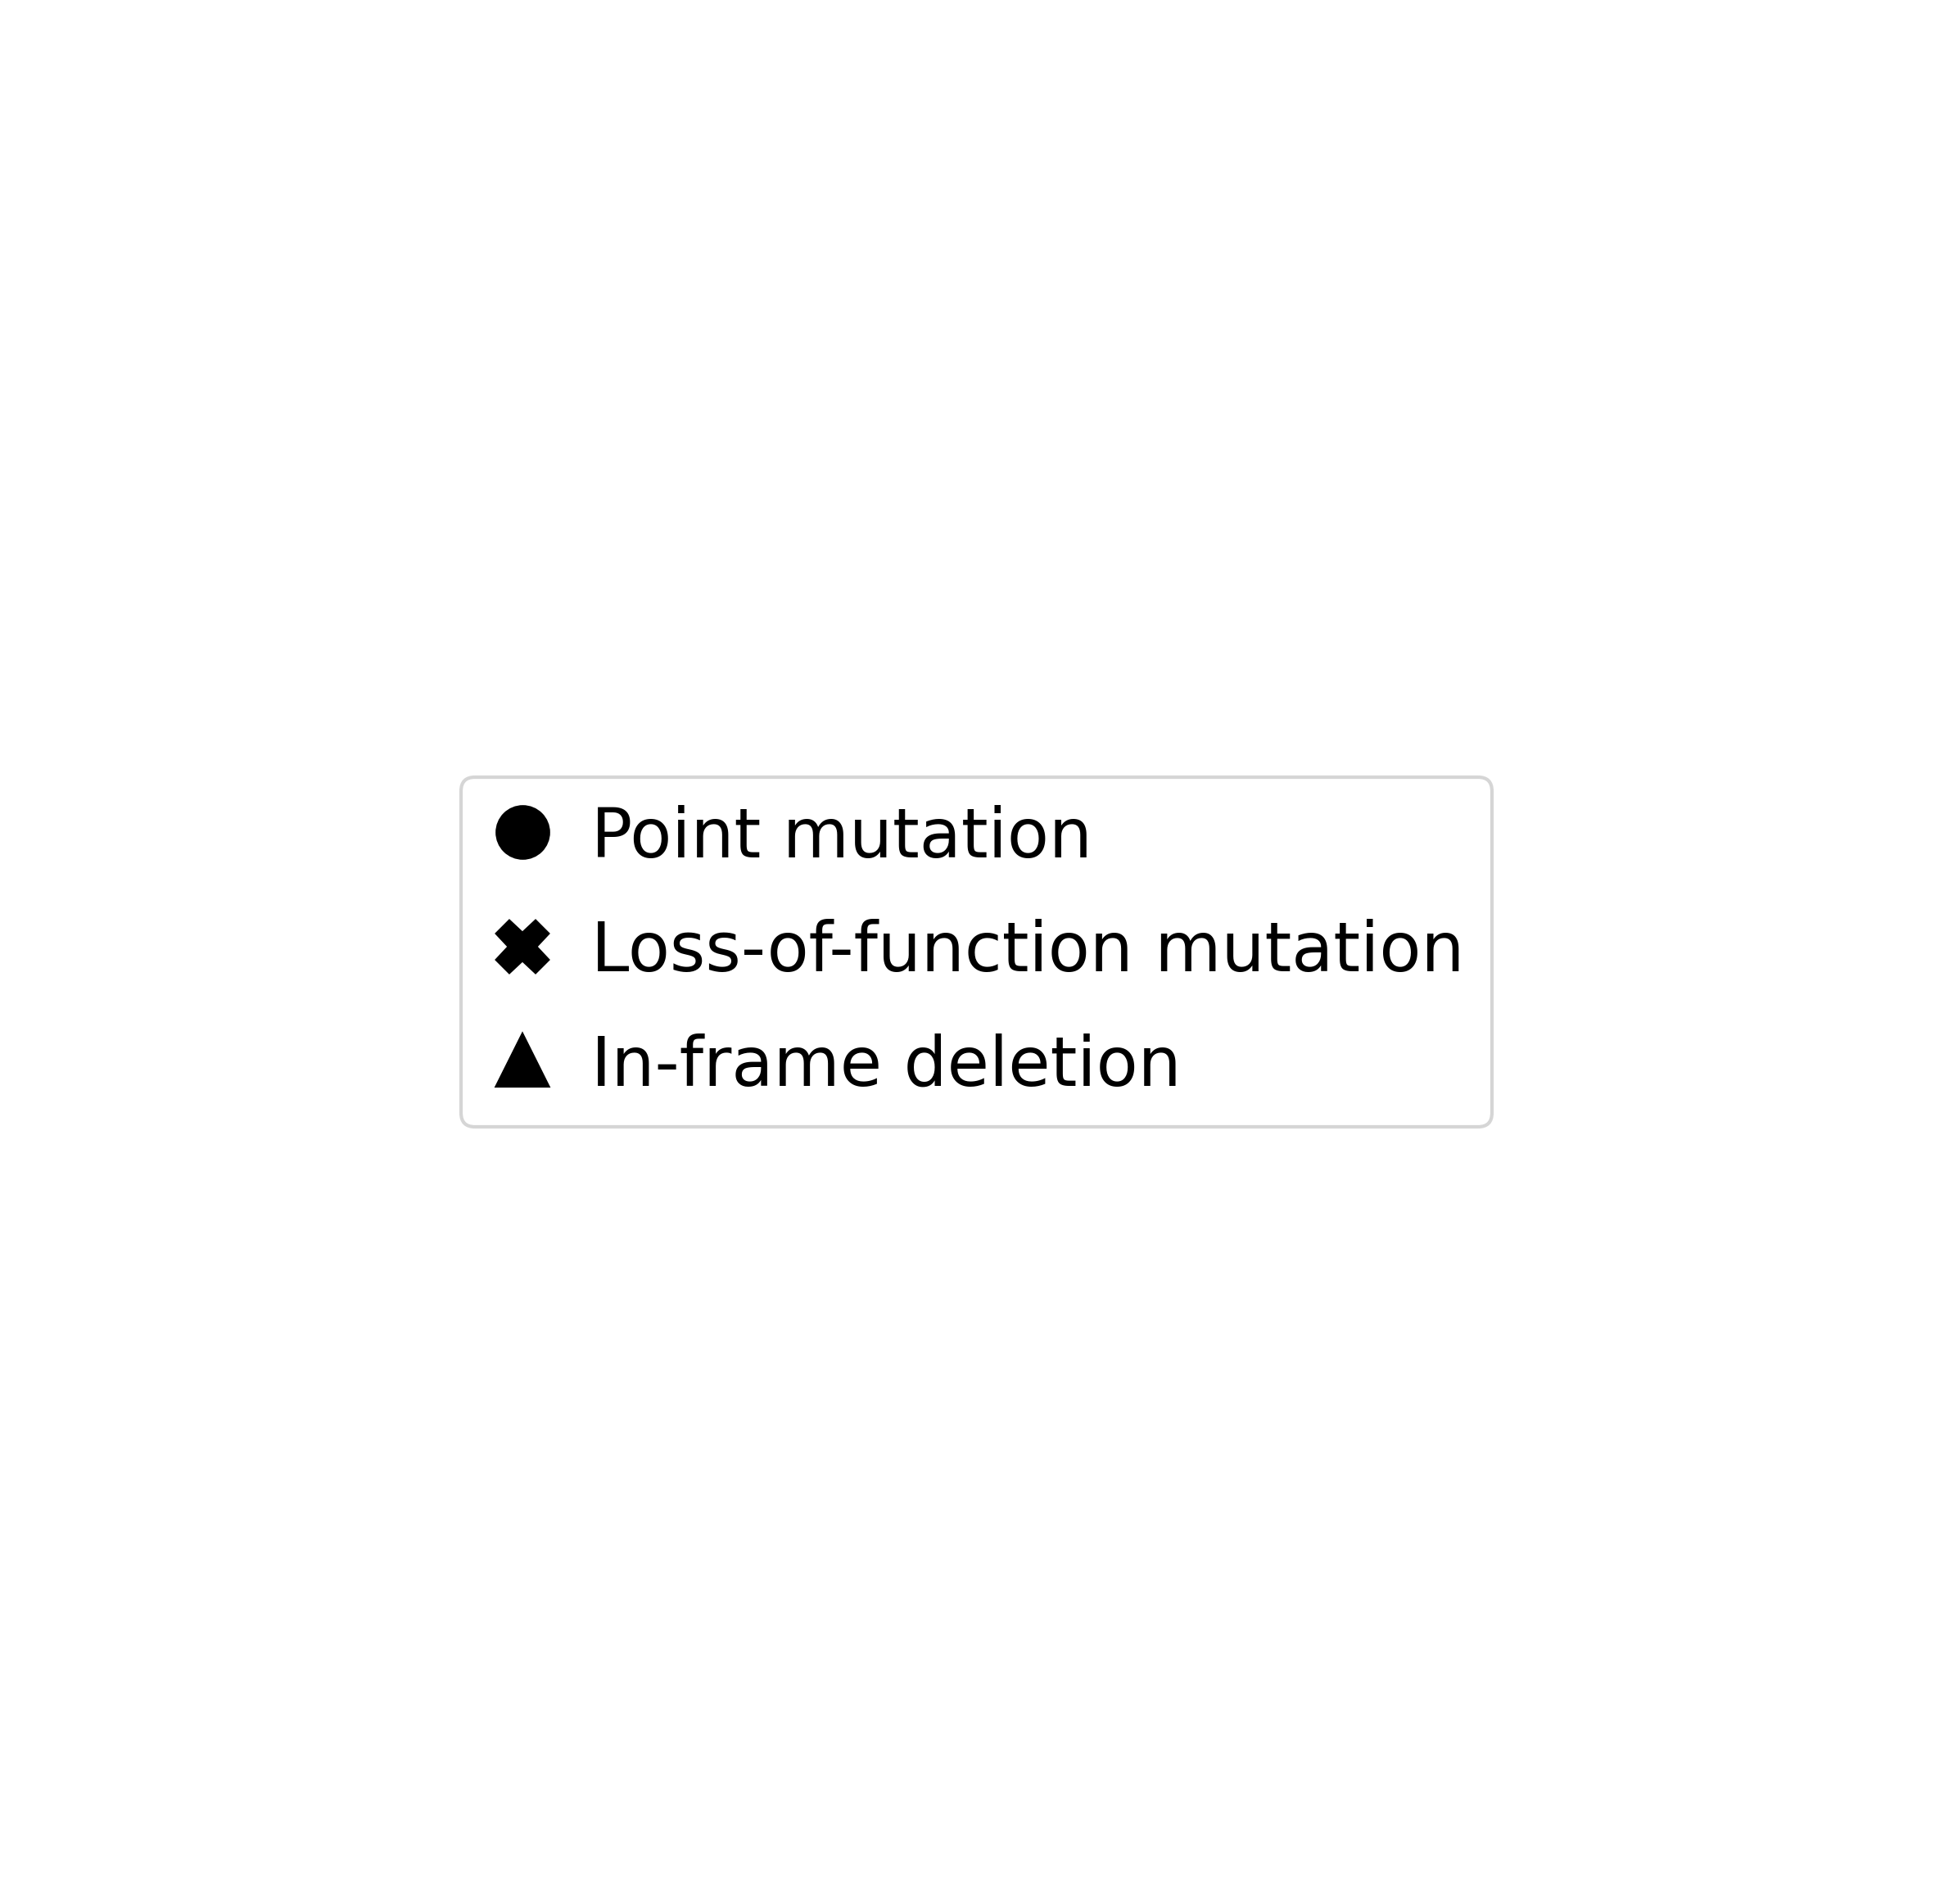

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

markers = {
    1: 'o',
    2: 'X',
    3: '^'
}

# Define labels for each marker
legend_labels = ['Point mutation', 'Loss-of-function mutation', 'In-frame deletion']

legend_handles = [
    mlines.Line2D([], [], color='black', marker=markers[key], linestyle='None',
                  markersize=15, label=label) 
    for key, label in zip(markers.keys(), legend_labels)
]

# Create the legend figure
legend_fig = plt.figure(figsize=(10, 10), dpi=300)

# Adjust these parameters to improve vertical alignment
legend = legend_fig.legend(
    handles=legend_handles, 
    fontsize=20,       
    loc='center', 
    handlelength=1,     
    handleheight=0.8,   
    labelspacing=0.7,   
    handletextpad=0.5,  
    handler_map={mlines.Line2D: HandlerLine2D(numpoints=1)}
)

# Hide the axes
plt.gca().set_axis_off()

plt.savefig('PATH_TO_OUTPUT_DIR', dpi=300, bbox_inches='tight')


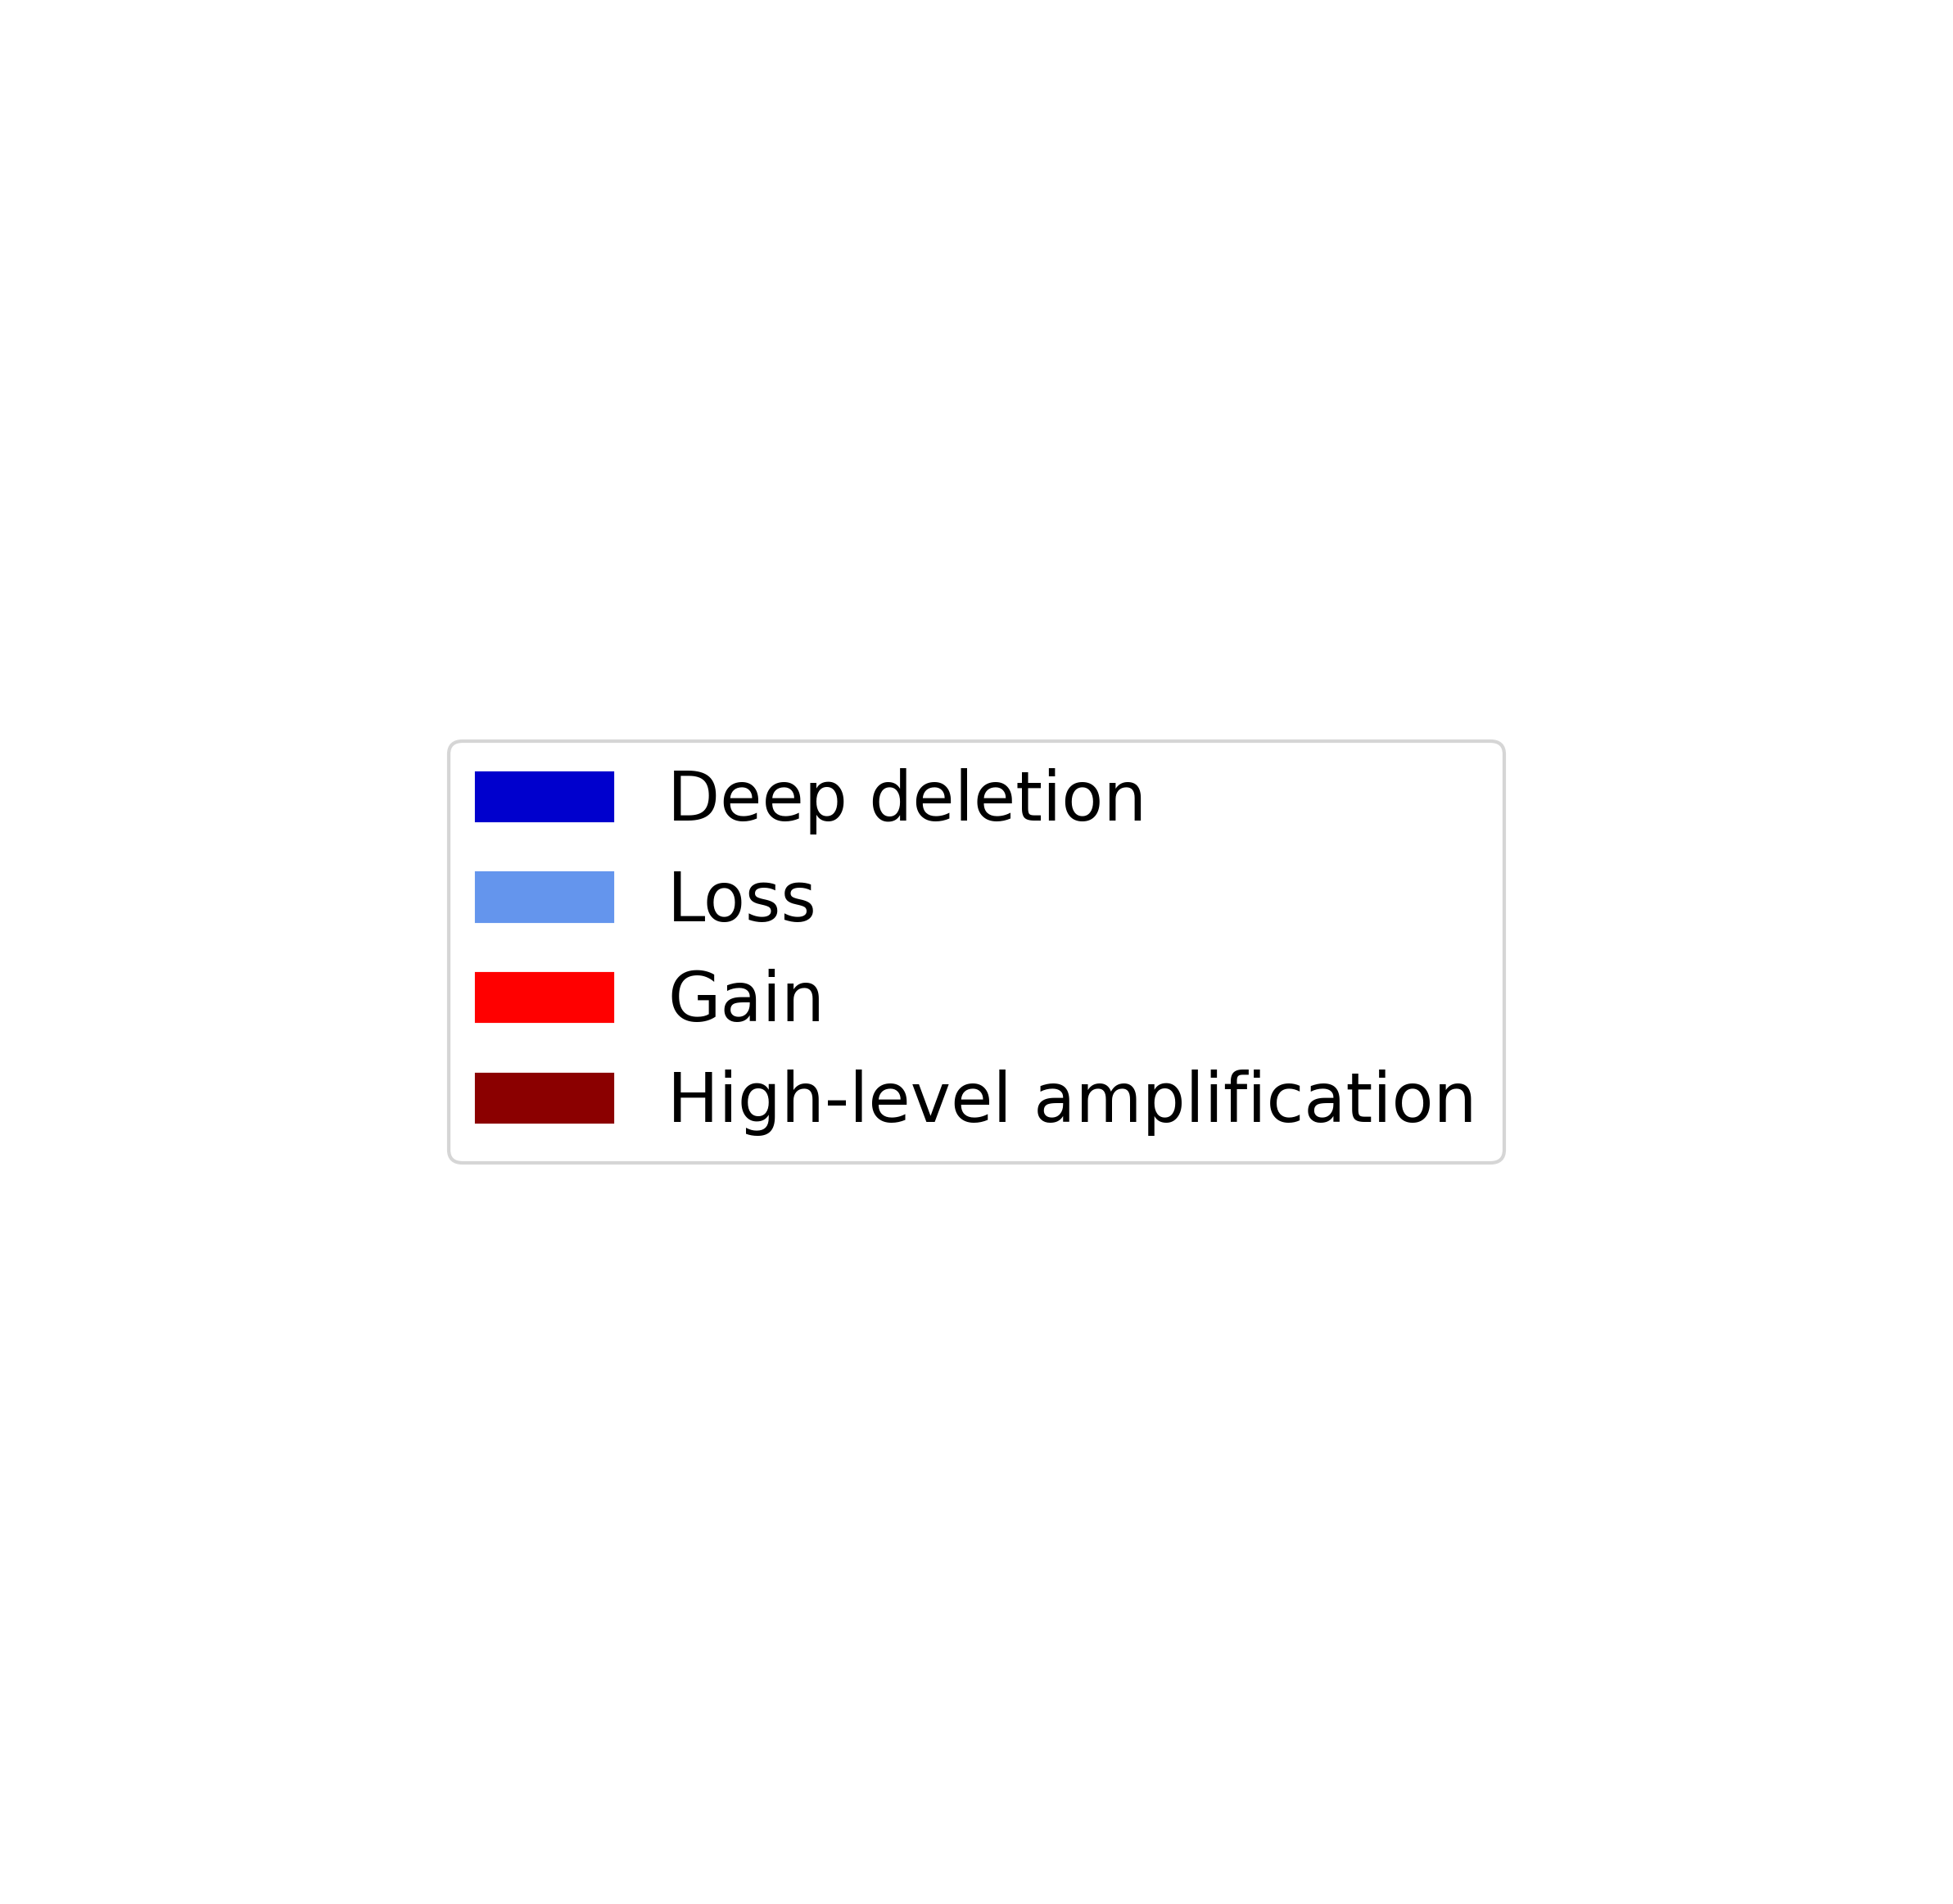

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define the categories and their corresponding colors
color_dict = {
    'Deep deletion': 'mediumblue',
    'Loss': 'cornflowerblue',
    'Gain': 'red',
    'High-level amplification': 'darkred'
}

# Create patches for each category
patches = [mpatches.Patch(color=color, label=label) for label, color in color_dict.items()]

# Create a new figure for the legend
fig_legend = plt.figure(figsize=(10, 10), dpi=300)

# Add the legend to the figure
legend = fig_legend.legend(handles=patches, loc='center', fontsize=20)

# Hide axes and adjust layout
plt.gca().set_axis_off()

# Save the legend
plt.savefig('PATH_TO_OUTPUT_DIR', dpi=300, bbox_inches='tight')
